# Convolutional Neural Network For Handwritten Digit Recognition Using PyTorch

## Importing All Essential Packages

In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.datasets import ImageFolder

from PIL import Image


## GPU Compatibility Check

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Inspecting Dataset

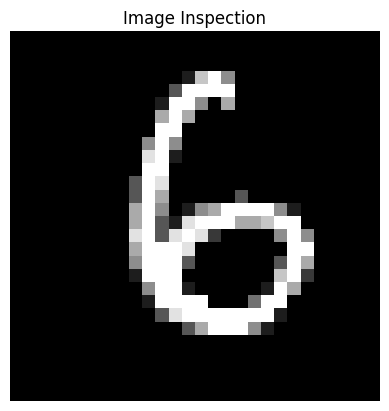

In [2]:
inspect_img = Image.open("../data/mnistmini/training/6/7220.png")

plt.title("Image Inspection")
plt.imshow(inspect_img, cmap = "gray")
plt.axis("off")
plt.show()

## Loading Dataset

In [19]:
seed = 67

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [62]:
train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees = 0, translate = (0.1, 0.1)),

    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])


In [ ]:
full_training_dataset = ImageFolder("../data/mnistmini/training")
indices = list(range(len(full_training_dataset)))
targets = full_training_dataset.targets

train_idx, val_idx = train_test_split(
    indices,
    test_size = 0.2,
    stratify = targets,
    random_state = seed
)

train_data = Subset(full_training_dataset, train_idx)
val_data = Subset(full_training_dataset, val_idx)

train_data.dataset.transform = train_transform
val_data.dataset.transfrom = val_transform

In [63]:
train_loader = DataLoader(
    train_data,
    batch_size = 32,
    shuffle = True
)

val_loader = DataLoader(
    val_data,
    batch_size = 32,
    shuffle = False
)

test_data = ImageFolder(
    '../data/mnistmini/testing', 
    transform = test_transform
)

test_loader = DataLoader(
    test_data,
    batch_size = 32,
    shuffle = False
)

## Model Architecture and Creation

In [52]:
class DigitCNN(nn.Module):
    def __init__(self):
        super(DigitCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, padding = 1),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),


            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [53]:
model = DigitCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode = "min",
    factor = 0.5,
    patience = 0.3,
)

In [54]:
history = {
    "loss": [],
    "val_loss": [],
    "accuracy": [],
    "val_accuracy": []
}

In [55]:
epochs = 30

best_val_acc = 0
patience = 7
patience_counter = 0

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim = 1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total


    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            predictions = outputs.argmax(dim = 1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    scheduler.step(val_loss)

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        patience_counter = 0

    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early Stopping Triggered")
        break

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch: {epoch + 1}/{epochs} "
        f"loss: {train_loss:.4f} "
        f"accuracy: {train_accuracy:.4f} "
        f"val_loss: {val_loss:.4f} "
        f"val_accuracy: {val_accuracy} "
        f"LR: {current_lr}"
    )
        



Epoch: 1/30 loss: 2.2789 accuracy: 0.1437 val_loss: 2.1424 val_accuracy: 0.325 LR: 0.001
Epoch: 2/30 loss: 1.8243 accuracy: 0.3875 val_loss: 1.2151 val_accuracy: 0.595 LR: 0.001
Epoch: 3/30 loss: 1.2992 accuracy: 0.5550 val_loss: 0.9319 val_accuracy: 0.675 LR: 0.001
Epoch: 4/30 loss: 0.9362 accuracy: 0.6937 val_loss: 0.7889 val_accuracy: 0.775 LR: 0.001
Epoch: 5/30 loss: 0.7251 accuracy: 0.7650 val_loss: 0.5126 val_accuracy: 0.85 LR: 0.001
Epoch: 6/30 loss: 0.6185 accuracy: 0.7975 val_loss: 0.6059 val_accuracy: 0.83 LR: 0.0005
Epoch: 7/30 loss: 0.5290 accuracy: 0.8350 val_loss: 0.4019 val_accuracy: 0.895 LR: 0.0005
Epoch: 8/30 loss: 0.4546 accuracy: 0.8588 val_loss: 0.4138 val_accuracy: 0.88 LR: 0.00025
Epoch: 9/30 loss: 0.4138 accuracy: 0.8712 val_loss: 0.3677 val_accuracy: 0.905 LR: 0.00025
Epoch: 10/30 loss: 0.3743 accuracy: 0.8962 val_loss: 0.3607 val_accuracy: 0.91 LR: 0.00025
Epoch: 11/30 loss: 0.3669 accuracy: 0.8775 val_loss: 0.3132 val_accuracy: 0.91 LR: 0.00025
Epoch: 12/30 l

## Model Evaluation

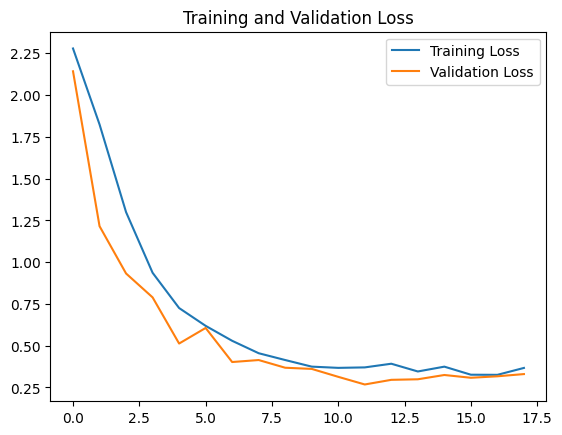

In [60]:
plt.title("Training and Validation Loss")

plt.plot(history["loss"], label = "Training Loss")
plt.plot(history['val_loss'], label = "Validation Loss")
plt.legend()

plt.show()

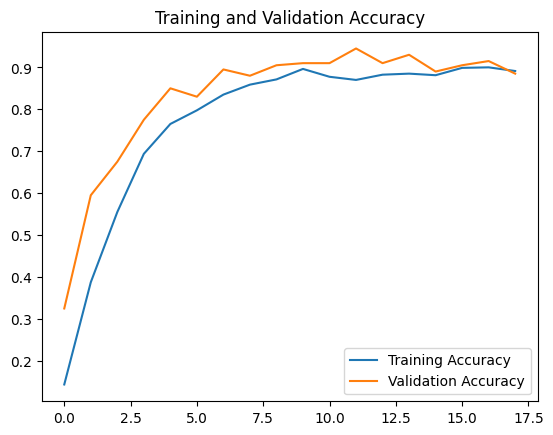

In [61]:
plt.title("Training and Validation Accuracy")

plt.plot(history["accuracy"], label = "Training Accuracy")
plt.plot(history['val_accuracy'], label = "Validation Accuracy")
plt.legend()

plt.show()

In [66]:
model.eval()

test_loss = 0
test_correct = 0
test_total = 0

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        predictions = outputs.argmax(dim = 1)

        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_accuracy = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1779
Test Accuracy: 0.9300


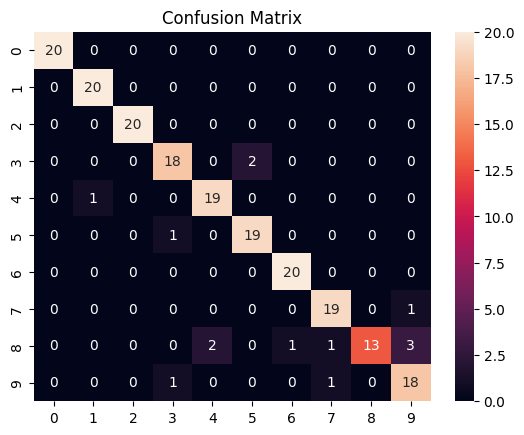

In [67]:
cm = confusion_matrix(all_labels, all_preds)

plt.title("Confusion Matrix")

sns.heatmap(cm, annot = True)

plt.show()

In [68]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.95      1.00      0.98        20
           2       1.00      1.00      1.00        20
           3       0.90      0.90      0.90        20
           4       0.90      0.95      0.93        20
           5       0.90      0.95      0.93        20
           6       0.95      1.00      0.98        20
           7       0.90      0.95      0.93        20
           8       1.00      0.65      0.79        20
           9       0.82      0.90      0.86        20

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



## Saving Model and Making Inferences

In [70]:
torch.save(
    model.state_dict(),
    "../models/cnn_digit_pytorch_model.pth"
)

In [71]:
saved_model = DigitCNN().to(device)
saved_model.load_state_dict(
    torch.load(
        "../models/cnn_digit_pytorch_model.pth",
        map_location = device
    )
)

<All keys matched successfully>

In [72]:
model.eval()

inference_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

In [75]:
def predict_digit(image_path):
    image = Image.open(image_path)

    plt.title("Actual Digit")

    plt.imshow(image, cmap = "gray")
    plt.axis("off")

    plt.show()

    image_tensor = inference_transform(image)
    image_tensor = image_tensor.unsqueeze(0)

    with torch.no_grad():
        outputs = model(image_tensor)
        prediction = outputs.argmax(dim = 1)

    print(f"Predicted Digit: {prediction.item()}")


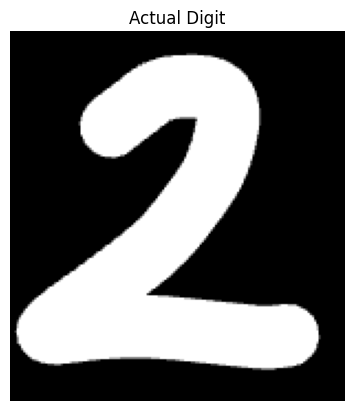

Predicted Digit: 2


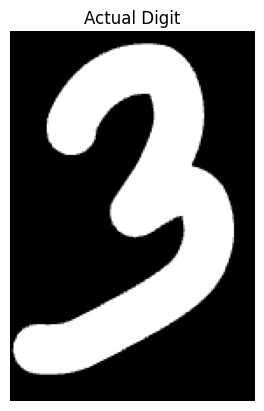

Predicted Digit: 3


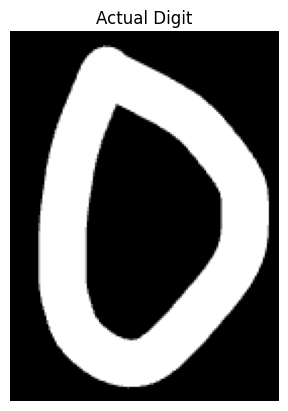

Predicted Digit: 0


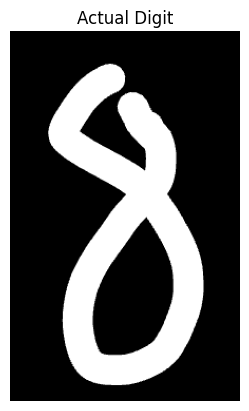

Predicted Digit: 3


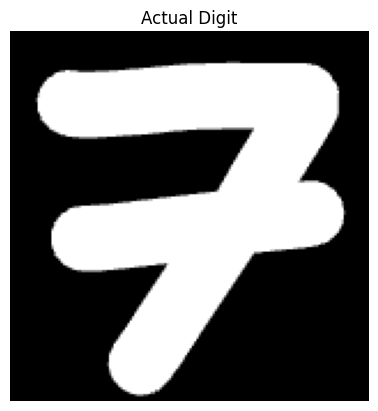

Predicted Digit: 2


In [79]:
predict_digit('../data/mnistmini/extra/Two.png')
predict_digit('../data/mnistmini/extra/Three.png')
predict_digit('../data/mnistmini/extra/Zero.png')
predict_digit('../data/mnistmini/extra/Eight.png')
predict_digit('../data/mnistmini/extra/seven.png')